In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
np.random.seed(42)
# Load breast cancer dataset
breast_cancer_data = load_breast_cancer()
X = breast_cancer_data.data
y = breast_cancer_data.target
feature_names = breast_cancer_data.feature_names
########################################
# Define a function to compute fitness for the maximise-ones problem
########################################
def ones_fitness(chromosome):
    """Calculate fitness for the maximise-ones problem."""
    return np.sum(chromosome)
########################################
# Define a function to create a random binary chromosome
#########################################
def create_population(pop_size, chromosome_length):
    """Create a population of random binary chromosomes."""
    population = []
    for i in range(pop_size):
        """Create one random binary chromosome."""
        chromosome = np.random.randint(0, 2, chromosome_length)
        
        population.append(chromosome)
    return np.array(population)
########################################
# Define a function for tournament selection
########################################
def tournament_selection(population, fitness_values, tournament_size):
    """Select one parent using tournament selection."""
    selected_indices = np.random.choice(len(population), tournament_size,
replace=False)
    
    selected_fitness = fitness_values[selected_indices]
    
    best_position = np.argmax(selected_fitness)
    best_index = selected_indices[best_position]
    
    return population[best_index].copy()
########################################
# Define a function for one-point crossover
########################################
def one_point_crossover(parent1, parent2, crossover_rate):
    """Create two children using one-point crossover."""
    random_value = np.random.rand()
    
    if random_value < crossover_rate:
        point = np.random.randint(1, len(parent1))
        child1_left = parent1[:point]
        child1_right = parent2[point:]
        
        child2_left = parent2[:point]
        child2_right = parent1[point:]
        
        child1 = np.concatenate((child1_left, child1_right))
        child2 = np.concatenate((child2_left, child2_right))
        
        return child1, child2
    
    return parent1.copy(), parent2.copy()
########################################
# Define a function for mutation
########################################
def mutate(chromosome, mutation_rate):
    """Apply bit-flip mutation to a chromosome."""
    mutated_chromosome = chromosome.copy()
    for i in range(len(mutated_chromosome)):
        random_value = np.random.rand()
        
        if random_value < mutation_rate:
            mutated_chromosome[i] = 1 - mutated_chromosome[i]
    
    return mutated_chromosome
########################################
# Define Genetic Algorithm Functions

ENGE707 Week 5 Lab: Genetic Algorithms
Running Maximise Ones Demo...
Maximise Ones Problem
Best solution: [1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0]
Best fitness: 16


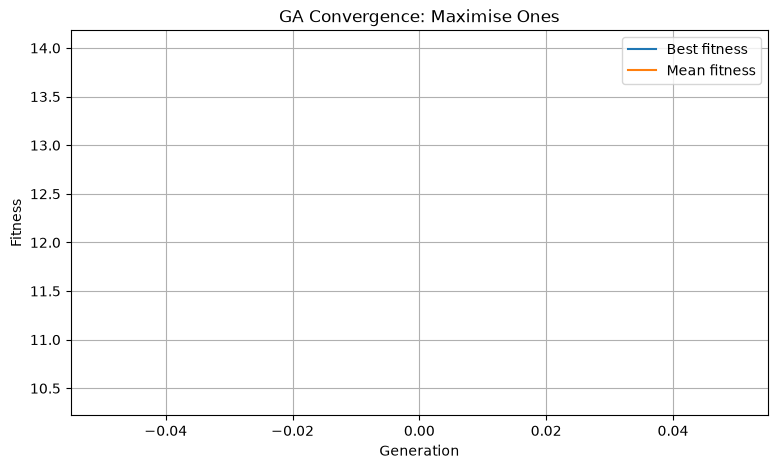

Running Parameter Experiments...
Parameter Experiment Results
Default settings Best fitness: 14 Best solution: [1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1]
Low mutation Best fitness: 15 Best solution: [1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1]
High mutation Best fitness: 14 Best solution: [1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 1]
Small population Best fitness: 15 Best solution: [1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1]
Large population Best fitness: 17 Best solution: [1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1]
Low crossover Best fitness: 16 Best solution: [1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1]


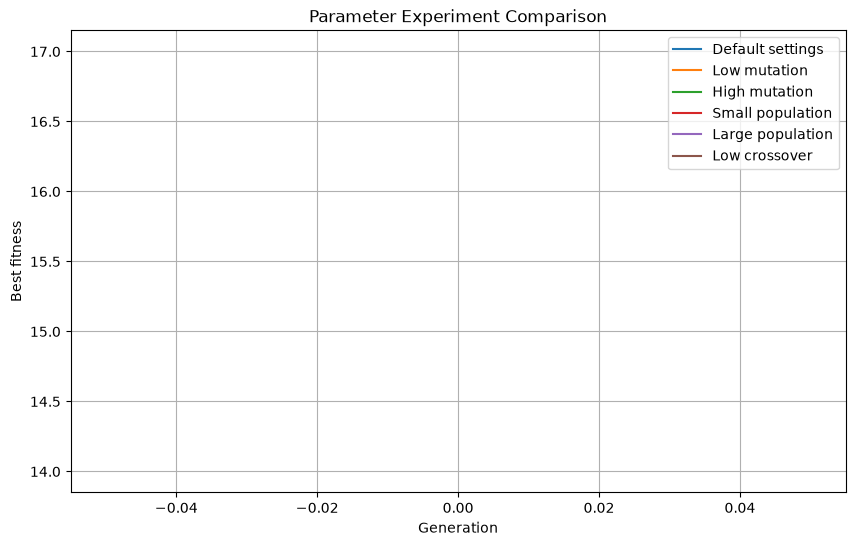

Running Feature Selection Demo...
Feature Selection Problem
Number of available features: 30
Best chromosome: [0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 0 0]
Number of selected features: 14
Selected feature indices: [ 3  7 10 11 12 13 14 15 16 18 19 20 21 22]
Selected feature names:
mean area
mean concave points
radius error
texture error
perimeter error
area error
smoothness error
compactness error
concavity error
symmetry error
fractal dimension error
worst radius
worst texture
worst perimeter
Best GA fitness: 0.937345443254153
Accuracy using all features: 0.9173420276354604


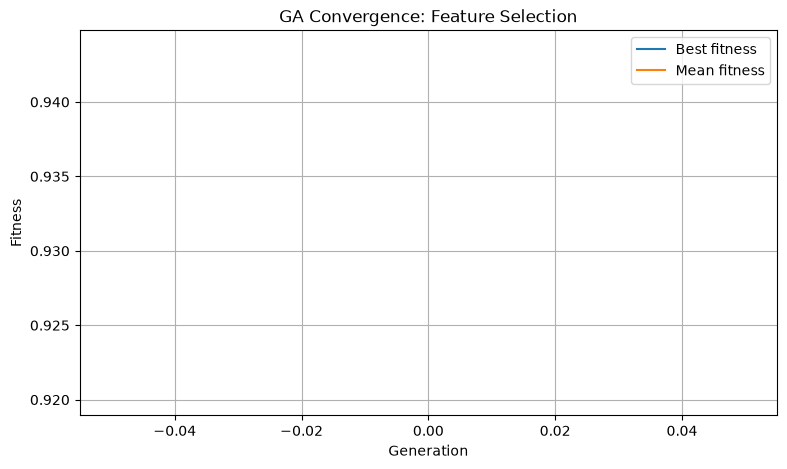

Lab complete


In [3]:
#########################################
from turtle import title
from unicodedata import name


def genetic_algorithm( fitness_function, chromosome_length, pop_size,
generations, crossover_rate, mutation_rate, tournament_size):
    """Run a binary Genetic Algorithm."""
    population = create_population(pop_size, chromosome_length)
    
    best_fitness_history = []
    mean_fitness_history = []
    
    for generation in range(generations):
        
        fitness_values = []
    
        for chromosome in population:
            score = fitness_function(chromosome)
            fitness_values.append(score)
            
    fitness_values = np.array(fitness_values)
    
    best_fitness = np.max(fitness_values)
    mean_fitness = np.mean(fitness_values)
    
    best_fitness_history.append(best_fitness)
    mean_fitness_history.append(mean_fitness)
    
    new_population = []
    
    while len(new_population) < pop_size:
        
        parent1 = tournament_selection( population, fitness_values,
    tournament_size )
        parent2 = tournament_selection( population, fitness_values,
    tournament_size )
        child1, child2 = one_point_crossover( parent1, parent2,
    crossover_rate )
        child1 = mutate(child1, mutation_rate)
        child2 = mutate(child2, mutation_rate)
        
        new_population.append(child1)
        
        if len(new_population) < pop_size:
            new_population.append(child2)

    population = np.array(new_population)

    # Evaluate final population
    final_fitness_values = []
    
    for chromosome in population:
        score = fitness_function(chromosome)
        final_fitness_values.append(score)
        
    final_fitness_values = np.array(final_fitness_values)
    
    best_index = np.argmax(final_fitness_values)
    
    best_solution = population[best_index]
    
    best_score = final_fitness_values[best_index]
    
    return ( best_solution, best_score, best_fitness_history,
    mean_fitness_history)

def plot_convergence(best_history, mean_history, title):
    """Plot best and mean fitness across generations."""
    plt.figure(figsize=(9, 5))
    plt.plot(best_history, label="Best fitness")
    plt.plot(mean_history, label="Mean fitness")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
########################################
# Task 1: Maximise Ones Problem
########################################
def run_maximise_ones_demo():
    """Run the maximise-ones Genetic Algorithm example."""
    
    best_solution, best_score, best_history, mean_history = genetic_algorithm(
        fitness_function=ones_fitness,
        chromosome_length=20,
        pop_size=30,
        generations=50,
        crossover_rate=0.8,
        mutation_rate=0.01,
        tournament_size=3
        )

    print("Maximise Ones Problem")
    print("Best solution:", best_solution)
    print("Best fitness:", best_score)
    plot_convergence( best_history, mean_history, "GA Convergence: Maximise Ones" )
########################################
# Task 2: Maximise Ones Problem
########################################
def run_parameter_experiments():
    """Run Genetic Algorithm experiments with different parameters."""
    experiments = [
    ["Default settings", 30, 50, 0.8, 0.01, 3],
    ["Low mutation", 30, 50, 0.8, 0.001, 3],
    ["High mutation", 30, 50, 0.8, 0.2, 3],
    ["Small population", 10, 50, 0.8, 0.01, 3],
    ["Large population", 100, 50, 0.8, 0.01, 3],
    ["Low crossover", 30, 50, 0.2, 0.01, 3]
    ]
    
    plt.figure(figsize=(10, 6))
    
    print("Parameter Experiment Results")
    
    for experiment in experiments:
        
        name = experiment[0]
        pop_size = experiment[1]
        generations = experiment[2]
        crossover_rate = experiment[3]
        mutation_rate = experiment[4]
        tournament_size = experiment[5]
        
        best_solution, best_score, best_history, mean_history =genetic_algorithm(
            fitness_function=ones_fitness,
            chromosome_length=20,
            pop_size=pop_size,
            generations=generations,
            crossover_rate=crossover_rate,
            mutation_rate=mutation_rate,
            tournament_size=tournament_size
            )

        print( name, "Best fitness:", best_score, "Best solution:",
best_solution)
        
        plt.plot(best_history, label=name)
        
    plt.xlabel("Generation")
    plt.ylabel("Best fitness")
    plt.title("Parameter Experiment Comparison")
    
    plt.legend()
    plt.grid(True)
    
    plt.show()
#########################################
# Define a function to compute fitness for the feature selection problem
#########################################
def feature_selection_fitness(chromosome):
    """
    Calculate fitness for feature selection using
    cross-validation accuracy and a feature penalty.
    """
    number_selected = np.sum(chromosome)
    # Avoid selecting zero features
    if number_selected == 0:
        return 0
    
    selected_features = np.where(chromosome == 1)[0]
    X_selected = X[:, selected_features]
    model = DecisionTreeClassifier(random_state=42)
    scores = cross_val_score( model, X_selected, y, cv=5, scoring="accuracy" )
    accuracy = np.mean(scores)
    penalty = 0.01 * ( number_selected / len(chromosome) )
    fitness = accuracy - penalty
    return fitness

#########################################
# Task 3: Feature Selection Problem
#########################################
def run_feature_selection_demo():
    """Run the Genetic Algorithm for feature selection."""
    number_of_features = X.shape[1]
    best_solution, best_score, best_history, mean_history = genetic_algorithm(
        fitness_function=feature_selection_fitness,
        chromosome_length=number_of_features,
        pop_size=30,
        generations=30,
        crossover_rate=0.8,
        mutation_rate=1 / number_of_features,
        tournament_size=3
    )
    selected_indices = np.where(best_solution == 1)[0]
    selected_names = feature_names[selected_indices]
    
    print("Feature Selection Problem")
    print("Number of available features:", number_of_features)
    print("Best chromosome:", best_solution)
    print( "Number of selected features:", len(selected_indices) )
    print( "Selected feature indices:", selected_indices )
    print("Selected feature names:")

    for name in selected_names:
        print(name)
    print("Best GA fitness:", best_score)
    
    # Accuracy using all features
    model = DecisionTreeClassifier(random_state=42)
    
    all_feature_scores = cross_val_score( model, X, y, cv=5,
scoring="accuracy" )
    
    all_feature_accuracy = np.mean(all_feature_scores)
    
    print( "Accuracy using all features:", all_feature_accuracy)
    
    plot_convergence( best_history, mean_history, "GA Convergence: Feature Selection" )

def lab_05():
    """Run all lab demonstrations."""
    print("ENGE707 Week 5 Lab: Genetic Algorithms")
    print("Running Maximise Ones Demo...")
    run_maximise_ones_demo()
    print("Running Parameter Experiments...")
    run_parameter_experiments()
    print("Running Feature Selection Demo...")
    run_feature_selection_demo()
    print("Lab complete")

if __name__ == "__main__":
    lab_05()
    

Activity 4

What happens when the mutation rate is too low?
    Reduces the genetic diversity and can cause the GA to converge slowly or get stuck in a suboptimal solution. 
    It reduces the chance of 0s becoming 1s
What happens when the mutaiton rate is too high?
    Intoduces too much randomness and can ruin a good solution due to frequent bit flips. 
How does population size affect convergence?
    Provides better genetic diversity that can develop an optimal solution. However, takes more computational time
Why can results differ between runs?
    Because variables are created through random means thus why each run is different

Activity 6

Why is a binary chromosome suitable for feature selection?
    It is suitable because a bit can clearly indicate whether a feature is included or excluded
    1 means that it is included and 0 means that it is excluded
Why should validation or cross-validation accuracy be used instead of training accuracy?
    Cross-validation accuracy provides a better estimate of how well the selected features will perform on unseen data. Training accuracy can be misleading because the model may overfit the training data. Using cross-validation makes the GA more likely to select features that generalise well.
What role does the penalty term play in the feature-selection fitness function?
    the penatly function discourages the selection of unecessary features. Tries to balance high accuracy with a smaller
    and more efficient feature set
How might the GA behave differently if the dataset had 5,000 features?
    Computational time and power would greatly increase. Process would become more expensive and there would be vastly more cross-validation required.
What are the risks of using a GA for machine learning model selection?
    Since GA uses randomly created variables, there is no guarantee that a global optimal solution can be found.
How could this GA be improved for larger data engineering problems?
    For larger data engineering problems, the GA could be improved using parallel fitness evaluation, adaptive mutation and crossover rates, early stopping, and caching previously evaluated solutions. Dimensionality-reduction techniques could also be used before the GA to reduce the search space. These improvements would reduce computation time while allowing the GA to explore more candidate solutions.

